# prise en main base Rystad


#### problèmes (réglés): 
* clés RE_ID en doublons ? 
* problèmes de décimales ',' et '.', séparation ; ou , 

In [ ]:
import pandas as pd, numpy as np
from pathlib import Path

DATA = Path("/Users/rratajczyk/Desktop/OilMarket/repo/Data")

Oil_Definition = ["Bitumen","Extra Heavy Oil","Heavy Oil 15-19",
                  "Heavy Oil 20-22","Sour (> 3%)","Regular","Light","Condensate"] #"Synthetic crude","NGL"]# pourquoi NGL/synthetic crude ne sont pas dans Oil_Definition de Coulomb (d'après la légende de leur figure)? 
Gas_Definition = ["Gas","LNG","Feed gas to LNG","Feed gas to Pipeline","Gas in Pipelines","GTL"]

def to_num(s):
    # dans les colonnes numériques la virgule est toujours décimale, et aucun séparateur de milliers 
    return pd.to_numeric(s.astype(str).str.replace(",", ".", regex=False),
                         errors="coerce").round(6)

def load(name, numeric_cols=()):
    df = pd.read_csv(DATA / name, encoding="latin-1", low_memory=False)
    for c in numeric_cols:
        if c in df.columns:
            df[c] = to_num(df[c])
    return df

eco_cols = ["Free Cash Flow","Royalty effects","Income Tax","Well Capex","Facility Capex",
            "Exploration Well Capex","G&G and Seismic capex","SG&A Opex","Transportation Opex",
            "Production Opex","Abandonment cost","Sum","Government Profit Oil","Lease Capex","Taxes Opex"]
res_cols = ["Resources (Million bbl)","1P Reserves (Million bbl)",
            "2P Reserves (Million bbl)","Technical recoverable resources (Million bbl)"]

asset    = load("Asset_Info.csv").drop_duplicates("RE ID")
prod     = load("Production.csv", ["Production (Million bbl)"])
reserves = pd.concat([load("Reserves_North_America.csv", res_cols),
                      load("Reserves_Rest.csv",          res_cols)], ignore_index=True)
eco      = pd.concat([load("Eco_North_America.csv", eco_cols),
                      load("Eco_Rest.csv",          eco_cols)], ignore_index=True)
deflator = load("Deflator.csv", ["Economics (MUSD)","Economics (MUSD real)"])
ci       = pd.read_csv(DATA / "CI_Full.csv", low_memory=False)   # déjà UTF-8

for nm, d in [("asset",asset),("prod",prod),("reserves",reserves),
              ("eco",eco),("deflator",deflator),("ci",ci)]:
    print(f"{nm:9s} {d.shape}")





asset     (103193, 82)
prod      (8546951, 8)
reserves  (27581380, 8)
eco       (10557390, 19)
deflator  (201, 3)
ci        (57217, 25)


### voir : Figure 1: Heterogeneity in upstream and midstream carbon intensities. , Coulomb et al.
(a) Carbon-intensity-based oil supply: as of 1992
Oil type
Bitumen
60
Carbon intensity (gCO2e/MJ)
40
Condensate
Extra Heavy Oil
Heavy Oil 15−19
Heavy Oil 20−23
Light
Regular
Sour (> 3%)

In [ ]:
prod.columns

Index(['RE ID', 'Asset', 'Year', 'Oil and Gas Detail', 'Data Type',
       'Data Confidence', 'Data Source', 'Production (Million bbl)'],
      dtype='str')

In [ ]:
reserves['Oil and Gas Detail'].value_counts()

Oil and Gas Detail
Gas                     8658599
NGL                     5460632
Regular                 5173677
Condensate              4405232
Light                   3306642
Heavy Oil 15-19          134546
Sour (> 3%)              123826
Heavy Oil 20-22          106821
Extra Heavy Oil           61463
Bitumen                   60033
Feed gas to LNG           39509
LNG                       39509
Synthetic crude            6462
CTG                        3337
GTL                         848
Gas in Pipelines            122
Feed gas to Pipeline        122
Name: count, dtype: int64

In [ ]:
COULOMB_T3 = {"Saudi Arabia":14,"Russia":12,"United States":10,"Iran":5,"China":5,
              "Mexico":4,"UAE":4,"Canada":4,"Venezuela":4,"Iraq":3,"Norway":3,
              "Kuwait":3,"Nigeria":3,"United Kingdom":2,"Brazil":2}

p = prod.copy()
p = p[p["Oil and Gas Detail"] != "Sum"]
p = p[~p["Asset"].str.contains("ther liquids|Refinery gains", na=False)]
p = p[(p["Year"] >= 1992) & (p["Year"] <= 2018)]
p = p[p["Oil and Gas Detail"].isin(Oil_Definition)]

p = p.merge(asset[["RE ID","Country"]], on="RE ID", how="left")
p["Country"] = p["Country"].replace({"Lybia":"Libya"})        # faute Rystad

# Neutral Zone -> 50/50 Saudi Arabia / Kuwait
nz = p[p["Country"] == "Neutral Zone"].copy(); nz["Production (Million bbl)"] /= 2
p = pd.concat([p[p["Country"] != "Neutral Zone"],
               nz.assign(Country="Saudi Arabia"), nz.assign(Country="Kuwait")])

ctry = p.groupby("Country")["Production (Million bbl)"].sum()
share = (100 * ctry / ctry.sum()).round(1).sort_values(ascending=False)

cmp3 = (share.rename("nous").to_frame()
        .assign(Coulomb=lambda d: d.index.map(COULOMB_T3)))
print("TOP 15 PRODUCTION:\n", cmp3.head(15))

# écart  moyen à la table de Coulomb 
print(f"Écart moyen absolu (MAPE) : {(((cmp3.head(15)['nous'] - cmp3.head(15)['Coulomb']).abs() / cmp3.head(15)['Coulomb']).mean() * 100).round(2)} %")

TOP 15 PRODUCTION:
                 nous_%  Coulomb_
Country                         
Saudi Arabia      13.2      14.0
Russia            11.2      12.0
United States     11.1      10.0
Iran               5.1       5.0
China              4.4       5.0
Canada             4.0       4.0
Mexico             4.0       4.0
UAE                3.9       4.0
Venezuela          3.8       4.0
Norway             3.2       3.0
Kuwait             3.1       3.0
Iraq               2.9       3.0
Nigeria            2.8       3.0
United Kingdom     2.3       2.0
Brazil             2.1       2.0
Écart moyen absolu (MAPE) : 5.66 %


## méthode de calcul: 

## $S_i = \frac{\sum_{t=1992}^{2018} q_{i,t}}{\sum_{t=1992}^{2018} Q_t}$
(notations q ou x pour l'extraction)

In [ ]:
COULOMB_T5 = {"Saudi Arabia":286,"Russia":143,"United States":190,"Iran":90,"China":46,
              "Mexico":25,"UAE":72,"Canada":101,"Venezuela":34,"Iraq":122,"Norway":21,
              "Kuwait":61,"Nigeria":26,"United Kingdom":13,"Brazil":62}

r = reserves.rename(columns={"Resources (Million bbl)":"Resources",
                             "1P Reserves (Million bbl)":"Reserves_1P",
                             "2P Reserves (Million bbl)":"Reserves_2P"})
r["Oil_Gas"] = np.where(r["Oil and Gas Detail"].isin(Oil_Definition), "Oil",
               np.where(r["Oil and Gas Detail"].isin(Gas_Definition), "Gas", "Other"))
r = r[(r["Oil_Gas"] == "Oil") & (r["Year"] == 2019)]
r = (r.groupby("RE ID", as_index=False)[["Resources","Reserves_1P","Reserves_2P"]].sum()
       .merge(asset[["RE ID","Country"]], on="RE ID", how="left"))
r["Country"] = r["Country"].replace({"Lybia":"Libya"})

nz = r[r["Country"] == "Neutral Zone"].copy()
for c in ["Resources","Reserves_1P","Reserves_2P"]: nz[c] /= 2
r = pd.concat([r[r["Country"] != "Neutral Zone"],
               nz.assign(Country="Saudi Arabia"), nz.assign(Country="Kuwait")])

out = r.groupby("Country")[["Resources","Reserves_1P","Reserves_2P"]].sum() / 1000  # -> Gb
out = out.assign(Coulomb_Resources=lambda d: d.index.map(COULOMB_T5))
print("Total monde Resources (Gb) :", round(out["Resources"].sum(), 0), " (papier ≈1518)")
print(out.loc[list(COULOMB_T5)].round(0))

Total monde Resources (Gb) : 1650.0  (papier ≈1518)
                Resources  Reserves_1P  Reserves_2P  Coulomb_Resources
Country                                                               
Saudi Arabia        291.0         66.0        107.0              286.0
Russia              148.0         51.0         79.0              143.0
United States       196.0         72.0         91.0              190.0
Iran                104.0         21.0         37.0               90.0
China                64.0         18.0         36.0               46.0
Mexico               21.0          5.0         11.0               25.0
UAE                  89.0         24.0         44.0               72.0
Canada              102.0         42.0         62.0              101.0
Venezuela            15.0          4.0          6.0               34.0
Iraq                111.0         20.0         48.0              122.0
Norway               18.0          6.0         12.0               21.0
Kuwait               55.0

### $2P = 1P + Probable$
Pandas effectue une agrégation verticale, donc on ne mélange jamais 2P avec 1P avec Reserves par ex (jamais de double comptage). 


Coulomb et al. définissent les réserves de 2019 en sommant la trajectoire d'extraction future prévue par Rystad dans son scénario par défaut (BAU), d'aujourd'hui jusqu'en 2100.
Mathématiquement : $R_{i, 2019} = \sum_{t=2019}^{2100} q_{i,t}^{BAU}$.
Cette définition exclut alors "les ressources qui ne devraient jamais être économiquement ou techniquement récupérables"  

Je cite:   
"A country’s stranded assets are expressed as the share of its 2019 recoverable reserves
that is left underground under a specific scenario. For each field (discovered before 2019),
we compute its 2019 oil reserves as the sum of its future productions up to 2100 based on
Rystad business-as-usual (BAU) scenario, as done in the rest of the paper (see Appendices
D.1 and D.2). This reserve measure thus excludes resources that are never expected to be
economically or technically recoverable. The “stranded assets” can thus be interpreted as
the assets that become unburnable due to mitigation policy (here the joint effect of demand
drop in the future compared to a BAU and supply recomposition).20 The last column of
20The amount of oil underground exceeds the proven reserves in our analysis. But oil resources not
26
Table 5 gives the 2019 reserves by country, and global reserves of about 1,518 Gb. Overall,
our global reserves estimates are on par with those of the rest of the literature (BP, 2019;
IEA, 2019; OPEC, 2019; BGR, 2020; EIA, 2021; Welsby et al., 2021) with an average value
of 1,598 Gb, a maximum of 1,790 Gb (BGR, 2020) and a minimum of 1,276 Gb (Welsby
et al., 2021)."  

$R_{i, 2019} = \sum_{t=2019}^{2100} q_{i,t}^{BAU}$





In [ ]:

print(prod['Data Type'].value_counts())
print(prod['Data Source'].value_counts())
print(prod['Year'].value_counts())


Data Type
Modeled          5580748
Sum              1993462
Researched        972733
Not Available          8
Name: count, dtype: int64
Data Source
Modeled                        5580748
Sum                            1993544
Government webpage              675269
Analyst estimate                146704
Annual Report                    60105
Other document                   53314
Company Press Releases           20213
Articles on oil&gas domains      11121
Investor Presentation             5864
Company Webpage                     46
Oilfield service Report             15
Not Available                        8
Name: count, dtype: int64
Year
2055    124954
2056    124908
2054    124666
2057    124546
2053    123909
         ...  
1904       696
1903       685
1902       632
1901       611
1900       569
Name: count, Length: 201, dtype: int64


In [ ]:

p = prod[(prod["Oil and Gas Detail"].isin(Oil_Definition)) & (prod["Data Type"] != "Sum")].copy()

# CAPACITÉ : Pic historique par gisement
capa_asset = p.groupby("RE ID")["Production (Million bbl)"].max().rename("Capacity")

#  RÉSERVES BAU  : Intégrale de la production future (2019-2100) (Coulomb)
res_bau = p[p["Year"] >= 2019].groupby("RE ID")["Production (Million bbl)"].sum().rename("Reserves BAU (Million bbl)")

# Méthode STATIQUE : agrégation 2019 
r = reserves[(reserves["Oil and Gas Detail"].isin(Oil_Definition)) & (reserves["Year"] == 2019)]
cols_res = ["1P Reserves (Million bbl)", "2P Reserves (Million bbl)", "Technical recoverable resources (Million bbl)"]
res_asset = r.groupby("RE ID")[cols_res].sum()


df_assets = (res_asset
             .join(capa_asset, how="outer")
             .join(res_bau, how="outer")
             .merge(asset[["RE ID", "Country"]], on="RE ID", how="left"))

# ZONE NEUTRE (50/50)
cols_to_split = cols_res + ["Capacity", "Reserves BAU (Million bbl)"]
nz = df_assets[df_assets["Country"] == "Neutral Zone"].copy()
nz[cols_to_split] /= 2

df_assets = pd.concat([
    df_assets[df_assets["Country"] != "Neutral Zone"], 
    nz.assign(Country="Saudi Arabia"), 
    nz.assign(Country="Kuwait")
])

# Agregagatio, par pays. 
tableau_final = df_assets.groupby("Country")[cols_to_split].sum().round(2)


print(tableau_final.sort_values("Reserves BAU (Million bbl)", ascending=False).head(15))

print("Total monde Reserves BAU (Gb) :", round(tableau_final["Reserves BAU (Million bbl)"].sum() / 1000, 2), " (papier ≈1518)")

               1P Reserves (Million bbl)  2P Reserves (Million bbl)  \
Country                                                               
Saudi Arabia                    66018.36                  107182.88   
United States                   72382.40                   91320.84   
Russia                          51081.54                   78907.08   
Iraq                            20466.18                   48163.85   
Canada                          41855.18                   61790.27   
Iran                            20519.49                   36765.64   
UAE                             24088.97                   43553.98   
China                           18490.56                   36034.40   
Kuwait                          14171.91                   23333.73   
Brazil                          10764.02                   30106.34   
Qatar                           11506.23                   21289.14   
Kazakhstan                      14704.69                   18852.81   
Argent

1. La base n'exporte pas l'agrégat strict "3P". La variable Technical recoverable resources est utilisée comme proxy de la borne supérieure absolue des volumes récupérables (incluant les ressources contingentes).
2. La capacité est modélisée comme la somme des pics de production historiques des gisements du pays.

In [ ]:
import matplotlib.pyplot as plt

# pour les déciles de la Figure 1b
def wquantile(values, weights, q):
    v = np.asarray(values, float); w = np.asarray(weights, float)
    m = np.isfinite(v) & np.isfinite(w) & (w > 0); v, w = v[m], w[m]
    if len(v) == 0: return np.nan
    o = np.argsort(v); v, w = v[o], w[o]
    cum = (np.cumsum(w) - 0.5*w) / w.sum()
    return np.interp(q, cum, v)

# prod_w : production oil par champ sur 1992-2018 (= poids des moyennes/déciles) 
prod_w = (prod[prod["Year"].between(1992, 2018) & prod["Oil and Gas Detail"].isin(Oil_Definition)]
          .groupby("RE ID", as_index=False)["Production (Million bbl)"].sum()
          .rename(columns={"Production (Million bbl)": "prod_w"}))

print("prod_w :", prod_w.shape, "| wquantile OK")

prod_w : (23631, 2) | wquantile OK


In [ ]:
# Costs_Included = Unit_Param$Costs_Included.  "coûts réels privés" (opex + capex + abandon),
# fiscalité (Royalty/Income Tax/Gvt Profit/Taxes Opex) exclue (transferts)
Costs_Included = ["Production Opex","Transportation Opex","SG&A Opex",
                  "Well Capex","Facility Capex","Exploration Well Capex",
                  "G&G and Seismic capex","Abandonment cost"]

deflator["Deflate_factor"] = deflator["Economics (MUSD real)"] / deflator["Economics (MUSD)"]
e = eco.merge(deflator[["Year","Deflate_factor"]], on="Year", how="left")
e["Deflate_factor"] = e["Deflate_factor"].fillna(1.0)
for c in Costs_Included:
    e[c] = e[c] * e["Deflate_factor"]               #  USD réels déflatés
e["cost_year"] = e[Costs_Included].sum(axis=1)

cost_tot = e.groupby("RE ID")["cost_year"].sum()
oil_tot  = (prod[prod["Oil and Gas Detail"].isin(Oil_Definition)]
            .groupby("RE ID")["Production (Million bbl)"].sum())
cost = (cost_tot / oil_tot).rename("cost_bbl").reset_index()   #  "Average" = sum(coûts)/sum(prod)
cost = cost.replace([np.inf, -np.inf], np.nan).dropna()
if cost["cost_bbl"].median() < 0:                   
    cost["cost_bbl"] = -cost["cost_bbl"]
print(cost["cost_bbl"].describe().round(2))

count    5.444000e+04
mean     6.503848e+17
std      1.517503e+20
min     -1.072152e+09
25%      3.763000e+01
50%      8.530000e+01
75%      2.482400e+02
max      3.540695e+22
Name: cost_bbl, dtype: float64


In [ ]:
print(" signe/magnitude des colonnes de coût (eco) ")
print(eco[Costs_Included].describe().T[["mean","50%","min","max"]].round(2))

oil_tot = (prod[prod["Oil and Gas Detail"].isin(Oil_Definition)]
           .groupby("RE ID")["Production (Million bbl)"].sum())
print("\nchamps oil_tot < 0.1 Mbbl :", int((oil_tot < 0.1).sum()), "/", len(oil_tot))

cic = (ci["CI_Final_EBA"] + ci["CI_midstream"])
print("\nCI combinée (kg/bbl) :", cic.describe().round(1).to_dict())

print("\nVenezuela - asset:", int((asset['Country']=='Venezuela').sum()),
      "| ci:", int((ci['Country']=='Venezuela').sum()))

— signe/magnitude des colonnes de coût (eco) —
                         mean   50%  min        max
Production Opex          5.51  0.04 -0.0   17569.51
Transportation Opex      3.19  0.02 -0.0   11178.16
SG&A Opex                3.05  0.02 -0.0   10468.30
Well Capex              29.56  0.17 -0.0  122579.50
Facility Capex          11.75  0.15 -0.0   46990.64
Exploration Well Capex   7.02  0.00 -0.0    2927.00
G&G and Seismic capex    0.45  0.04  0.0    2361.26
Abandonment cost         1.70  0.00 -0.0    9503.23

champs oil_tot < 0.1 Mbbl : 17364 / 60861

CI combinée (kg/bbl) : {'count': 57217.0, 'mean': 139.9, 'std': 3528.6, 'min': 46.5, '25%': 62.8, '50%': 70.1, '75%': 82.3, 'max': 627771.9}

Venezuela — asset: 667 | ci: 527


In [ ]:
Costs_Included = ["Production Opex","Transportation Opex","SG&A Opex",
                  "Well Capex","Facility Capex","Exploration Well Capex",
                  "G&G and Seismic capex","Abandonment cost"]

deflator["Deflate_factor"] = deflator["Economics (MUSD real)"] / deflator["Economics (MUSD)"]
e = eco.merge(deflator[["Year","Deflate_factor"]], on="Year", how="left")
e["Deflate_factor"] = e["Deflate_factor"].fillna(1.0)
e[Costs_Included] = e[Costs_Included].fillna(0)
for c in Costs_Included:
    e[c] = e[c] * e["Deflate_factor"]
cost_tot = e.groupby("RE ID")[Costs_Included].sum().sum(axis=1)

g = prod[prod["Oil and Gas Detail"].isin(Oil_Definition + Gas_Definition)].copy()
g["is_oil"] = g["Oil and Gas Detail"].isin(Oil_Definition)
tot  = g.groupby("RE ID")["Production (Million bbl)"].sum()
oilp = g[g["is_oil"]].groupby("RE ID")["Production (Million bbl)"].sum()

cost = pd.DataFrame({"cost_tot": cost_tot}).join(tot.rename("tot")).join(oilp.rename("oil_tot"))
cost = cost[cost["oil_tot"].fillna(0) >= 0.1]            # vire les champs ~sans oil (division explosive)
cost["cost_bbl"] = cost["cost_tot"] / cost["tot"]        # coûts / production totale (boe) = part oil imputée
cost = cost.replace([np.inf,-np.inf], np.nan).dropna(subset=["cost_bbl"]).reset_index()
print(cost["cost_bbl"].describe().round(2))

count    43487.00
mean        62.64
std        455.12
min          2.05
25%         20.65
50%         32.44
75%         53.02
max      65533.46
Name: cost_bbl, dtype: float64


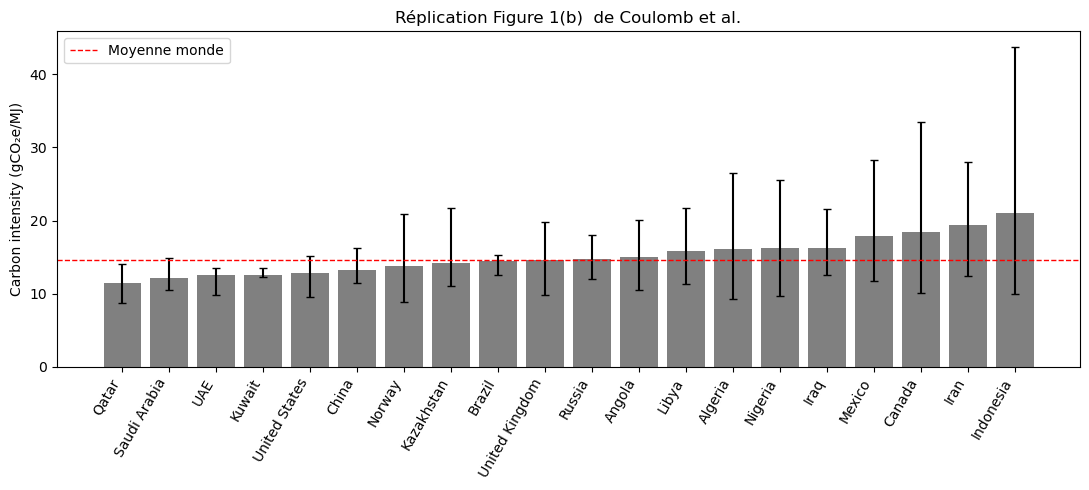

In [ ]:
ci2 = ci.rename(columns={"REID":"RE ID"})
UP, MID = "CI_Final_EBA", "CI_midstream"
MJ_PER_BBL = 6120.0

d = (ci2[["RE ID", UP, MID]].dropna()
     .assign(CI_comb=lambda x: x[UP] + x[MID])
     .merge(asset[["RE ID","Country"]], on="RE ID", how="left")
     .merge(prod_w, on="RE ID", how="left"))
d = d[d["CI_comb"] < 300]                         # CI extrêmes 
d["Country"] = d["Country"].replace({"Lybia":"Libya"})
d = d.dropna(subset=["Country","prod_w"]); d = d[d["prod_w"] > 0]
d = d[d["Country"].isin(d.groupby("Country")["prod_w"].sum().nlargest(20).index)]

def agg(g):
    k = 1000/MJ_PER_BBL
    return pd.Series({"mean": np.average(g["CI_comb"], weights=g["prod_w"])*k,
                      "p10": wquantile(g["CI_comb"], g["prod_w"], .10)*k,
                      "p90": wquantile(g["CI_comb"], g["prod_w"], .90)*k})
bars = d.groupby("Country").apply(agg, include_groups=False).sort_values("mean")

lower = (bars["mean"] - bars["p10"]).clip(lower=0)   
upper = (bars["p90"] - bars["mean"]).clip(lower=0)

fig, ax = plt.subplots(figsize=(11,5))
ax.bar(bars.index, bars["mean"], color="grey")
ax.errorbar(bars.index, bars["mean"], yerr=[lower, upper],
            fmt="none", ecolor="black", capsize=3)
ax.axhline(np.average(d["CI_comb"], weights=d["prod_w"])*1000/MJ_PER_BBL,
           color="red", ls="--", lw=1, label="Moyenne monde")
ax.set_ylabel("Carbon intensity (gCO₂e/MJ)")
ax.set_title("Réplication Figure 1(b)  de Coulomb et al.")
plt.xticks(rotation=60, ha="right"); ax.legend(); plt.tight_layout(); plt.show()

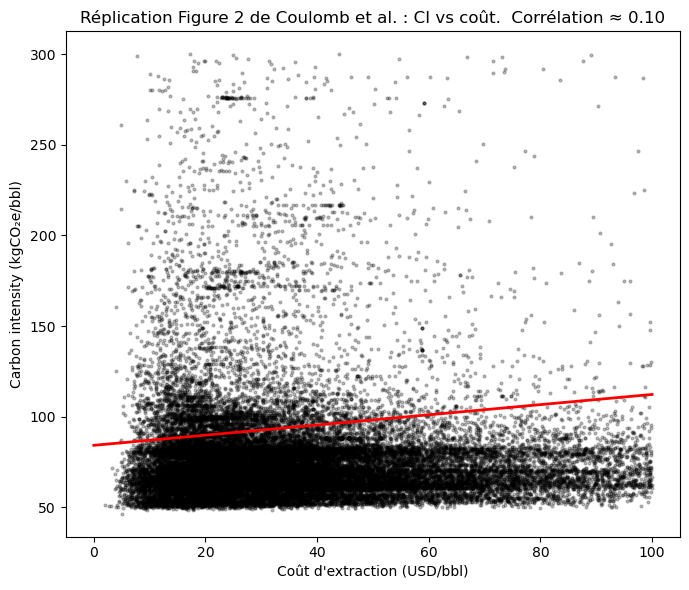

In [ ]:
d2 = (ci2[["RE ID", UP, MID]].dropna()
      .assign(CI_comb=lambda x: x[UP] + x[MID])      # kgCO2e/bbl
      .merge(cost, on="RE ID", how="inner")
      .merge(prod_w, on="RE ID", how="left"))
d2 = d2[(d2["CI_comb"] < 300) & d2["cost_bbl"].between(0,100)].dropna(subset=["CI_comb","cost_bbl"])

w = d2["prod_w"].fillna(0).clip(lower=0).to_numpy() + 1e-9
C = np.cov(np.vstack([d2["cost_bbl"], d2["CI_comb"]]), aweights=w)
corr = C[0,1] / np.sqrt(C[0,0]*C[1,1])
b, a = np.polyfit(d2["cost_bbl"], d2["CI_comb"], 1, w=np.sqrt(w))

fig, ax = plt.subplots(figsize=(7,6))
ax.scatter(d2["cost_bbl"], d2["CI_comb"], s=4, alpha=.25, color="black")
xs = np.linspace(0,100,50); ax.plot(xs, b*xs+a, "r-", lw=2)
ax.set_xlabel("Coût d'extraction (USD/bbl)")
ax.set_ylabel("Carbon intensity (kgCO₂e/bbl)")
ax.set_title(f"Réplication Figure 2 de Coulomb et al. : CI vs coût.  Corrélation ≈ {corr:.2f}")
plt.tight_layout(); plt.show()

In [ ]:
import pandas as pd 
import numpy as np 

df_asset_info = pd.read_csv('/Users/rratajczyk/Desktop/OilMarket/repo/Data/Asset_Info.csv', encoding='Latin-1',nrows=1000)
df_reserves_NA = pd.read_csv('/Users/rratajczyk/Desktop/OilMarket/repo/Data/Reserves_North_America.csv',  encoding='Latin-1',nrows=1000)
df_reserves_rest = pd.read_csv('/Users/rratajczyk/Desktop/OilMarket/repo/Data/Reserves_Rest.csv', encoding='Latin-1',nrows=1000)
df_production = pd.read_csv('/Users/rratajczyk/Desktop/OilMarket/repo/Data/Production.csv',  encoding='Latin-1',nrows=1000)
df_eco_NA = pd.read_csv('/Users/rratajczyk/Desktop/OilMarket/repo/Data/Eco_North_America.csv',  encoding='Latin-1',nrows=1000)
df_eco_rest = pd.read_csv('/Users/rratajczyk/Desktop/OilMarket/repo/Data/Eco_Rest.csv',  encoding='Latin-1',nrows=1000)
df_Deflator = pd.read_csv('/Users/rratajczyk/Desktop/OilMarket/repo/Data/Deflator.csv',  encoding='Latin-1',nrows=1000)
df_Carbon_Intensity = pd.read_csv('/Users/rratajczyk/Desktop/OilMarket/repo/Data/CI_Full.csv',  encoding='Latin-1',nrows=1000)

In [ ]:

print(f"NaN = {df_reserves_rest['Resources (Million bbl)'].isna().sum() / len(df_reserves_rest['Resources (Million bbl)']) * 100:.2f}%")

NaN = 0.00%


In [ ]:
df_asset_info['Asset Type'].value_counts()

Asset Type
Field                   635
License relinquished    320
License                  45
Name: count, dtype: int64

In [ ]:
# clé commune : RE_ID (+Year pour les données de panel)
df_main = pd.merge(df_prod, df_eco, on=['RE ID', 'Year'], how='inner')

df_main = pd.merge(df_main, df_asset, on='RE ID', how='left') # peut créer des NaN pour les gisements présents dans prod/eco mais absents de asset_info, à vérifier
df_main2 = pd.merge(df_main,df_asset,on='RE ID', how='inner') 
print(df_main.shape, df_main2.shape) 

(2769888, 12) (2769872, 15)


In [ ]:
df_asset[df_asset['Discovery Year'] >= 2019].value_counts()

RE ID    Region          Country      Discovery Year
AEF0185  Middle East     UAE          2020.0            1
NOF0687  Western Europe  Norway       2024.0            1
NZF0071  Australasia     New Zealand  2020.0            1
NOF0694  Western Europe  Norway       2025.0            1
NOF0693  Western Europe  Norway       2025.0            1
                                                       ..
GAF0208  West Africa     Gabon        2023.0            1
GAF0207  West Africa     Gabon        2022.0            1
GAF0205  West Africa     Gabon        2022.0            1
GAF0204  West Africa     Gabon        2021.0            1
ZWF0002  East Africa     Zimbabwe     2022.0            1
Name: count, Length: 1363, dtype: int64

###### CIRED